# 07 — Feature Selection

Train a simple Random Forest per species to identify which environmental
features matter most for Swiss plant distributions. Use the importance
rankings to select features for the SOM clustering step.

**Approach**: For each species, sample presence pixels (from GBIF) and
pseudo-absence pixels (random background), extract feature values,
train RF, collect feature importances. Aggregate across species.

### Load data

In [2]:
import config
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray
from s3_utils import load_zarr

# Feature stack
ds = load_zarr(config.FEATURE_STACK_ZARR)
feature_names = [v for v in ds.data_vars if v != 'spatial_ref']
print(f'{len(feature_names)} features: {feature_names}')

# GBIF occurrences
gbif = pd.read_parquet('swiss_occurences.parquet')
print(f'GBIF records: {len(gbif):,}')


21 features: ['aspect_cos', 'aspect_sin', 'bio1', 'bio12', 'bio15', 'bio18', 'bio4', 'canopy_height', 'forest_edge_dist', 'human_footprint', 'lc_built-up', 'lc_cropland', 'lc_grassland', 'lc_permanent_water_bodies', 'lc_snow_and_ice', 'lc_tree_cover', 'ndvi_max', 'plan_curvature', 'profile_curvature', 'slope', 'twi']
GBIF records: 14,161,132


### Select species and extract samples

In [3]:
TARGET_SPECIES = [
    'Picea abies',            # montane forest
    'Fagus sylvatica',        # lowland forest
    'Trifolium pratense',     # grassland
    'Potentilla erecta',      # alpine grassland
    'Phragmites australis',   # wetland
    'Senecio inaequidens',    # invasive / urban
]

# Filter to Swiss bounds and valid coords
from geo_utils import BOUNDS
gbif_ch = gbif[
    (gbif['decimallatitude'] >= BOUNDS['lat_min']) &
    (gbif['decimallatitude'] <= BOUNDS['lat_max']) &
    (gbif['decimallongitude'] >= BOUNDS['lon_min']) &
    (gbif['decimallongitude'] <= BOUNDS['lon_max'])
].copy()
print(f'Records within Swiss bounds: {len(gbif_ch):,}')

for sp in TARGET_SPECIES:
    n = (gbif_ch['species'] == sp).sum()
    print(f'  {sp:30s} {n:>7,} records')


Records within Swiss bounds: 14,159,847
  Picea abies                     71,959 records
  Fagus sylvatica                 56,558 records
  Trifolium pratense              84,598 records
  Potentilla erecta               63,767 records
  Phragmites australis            60,328 records
  Senecio inaequidens            196,214 records


### Build presence/absence samples per species

In [4]:
from rasterio.transform import rowcol

ref = ds[feature_names[0]]
transform = ref.rio.transform()
grid_shape = ref.shape

N_ABSENCE = 10_000  # pseudo-absences per species
N_PRESENCE_CAP = 10_000  # cap presence to balance

rng = np.random.default_rng(42)


def extract_features_at_points(lats, lons):
    """Extract feature values at lat/lon points from the xarray Dataset."""
    rows, cols = rowcol(transform, lons, lats)
    rows = np.array(rows)
    cols = np.array(cols)

    # Clip to grid bounds
    valid = (
        (rows >= 0) & (rows < grid_shape[0]) &
        (cols >= 0) & (cols < grid_shape[1])
    )
    rows, cols = rows[valid], cols[valid]

    X = np.empty((len(rows), len(feature_names)), dtype=np.float32)
    for j, name in enumerate(feature_names):
        X[:, j] = ds[name].values[rows, cols]

    # Drop rows with NaN
    finite = np.isfinite(X).all(axis=1)
    return X[finite]


# Build samples for each species
species_data = {}
for sp in TARGET_SPECIES:
    occ = gbif_ch[gbif_ch['species'] == sp]
    lats = occ['decimallatitude'].values
    lons = occ['decimallongitude'].values

    # Subsample if too many
    if len(lats) > N_PRESENCE_CAP:
        idx = rng.choice(len(lats), N_PRESENCE_CAP, replace=False)
        lats, lons = lats[idx], lons[idx]

    X_pres = extract_features_at_points(lats, lons)

    # Random pseudo-absences within Swiss bounds
    abs_lats = rng.uniform(BOUNDS['lat_min'], BOUNDS['lat_max'], N_ABSENCE)
    abs_lons = rng.uniform(BOUNDS['lon_min'], BOUNDS['lon_max'], N_ABSENCE)
    X_abs = extract_features_at_points(abs_lats, abs_lons)

    X = np.vstack([X_pres, X_abs])
    y = np.concatenate([np.ones(len(X_pres)), np.zeros(len(X_abs))])

    species_data[sp] = (X, y)
    print(f'{sp:30s}  presence={len(X_pres):,}  absence={len(X_abs):,}')


Picea abies                     presence=10,000  absence=9,820
Fagus sylvatica                 presence=10,000  absence=9,838
Trifolium pratense              presence=10,000  absence=9,844
Potentilla erecta               presence=10,000  absence=9,841
Phragmites australis            presence=10,000  absence=9,852
Senecio inaequidens             presence=10,000  absence=9,830


### Train RF and collect importances

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

importances = {}

for sp, (X, y) in species_data.items():
    rf = RandomForestClassifier(
        n_estimators=200, max_depth=15, n_jobs=-1, random_state=42
    )
    # Quick cross-val to check the model isn't garbage
    scores = cross_val_score(rf, X, y, cv=5, scoring='roc_auc')
    rf.fit(X, y)

    importances[sp] = rf.feature_importances_
    print(f'{sp:30s}  AUC={scores.mean():.3f} ± {scores.std():.3f}')

print('\nAll models trained.')


Picea abies                     AUC=0.985 ± 0.001
Fagus sylvatica                 AUC=0.980 ± 0.001
Trifolium pratense              AUC=0.983 ± 0.002
Potentilla erecta               AUC=0.986 ± 0.001
Phragmites australis            AUC=0.992 ± 0.001
Senecio inaequidens             AUC=0.991 ± 0.001

All models trained.


### Aggregate and rank features

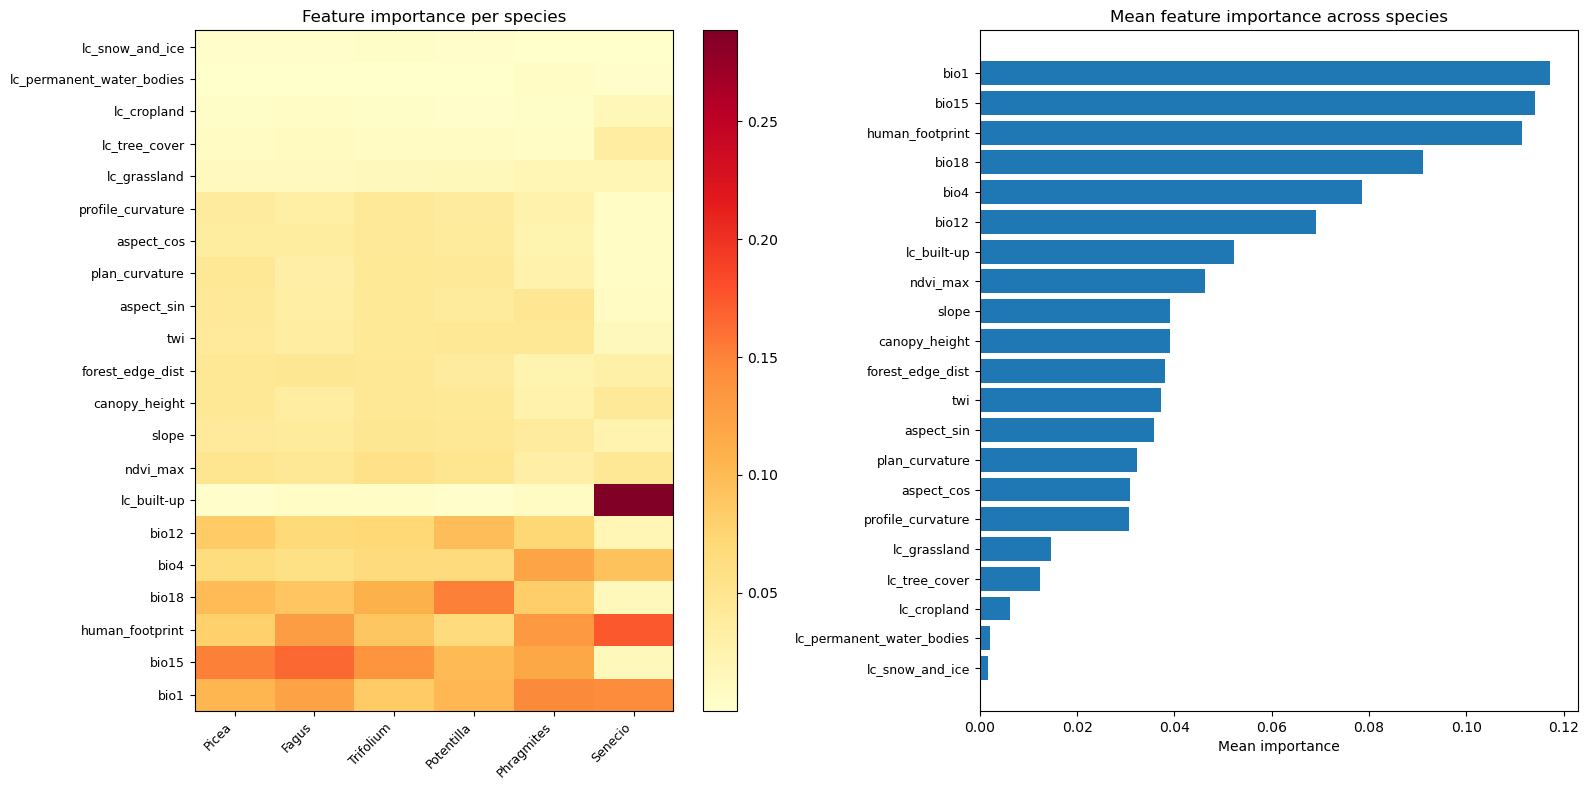


Feature ranking (mean importance):
   1. bio1                      0.1172
   2. bio15                     0.1142
   3. human_footprint           0.1115
   4. bio18                     0.0912
   5. bio4                      0.0785
   6. bio12                     0.0691
   7. lc_built-up               0.0522
   8. ndvi_max                  0.0462
   9. slope                     0.0391
  10. canopy_height             0.0390
  11. forest_edge_dist          0.0380
  12. twi                       0.0372
  13. aspect_sin                0.0358
  14. plan_curvature            0.0324
  15. aspect_cos                0.0308
  16. profile_curvature         0.0307
  17. lc_grassland              0.0146
  18. lc_tree_cover             0.0124
  19. lc_cropland               0.0061
  20. lc_permanent_water_bodies 0.0021
  21. lc_snow_and_ice           0.0017


In [6]:
import matplotlib.pyplot as plt

# Build importance DataFrame
imp_df = pd.DataFrame(importances, index=feature_names)
imp_df['mean'] = imp_df.mean(axis=1)
imp_df = imp_df.sort_values('mean', ascending=True)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Per-species heatmap
im = ax1.imshow(imp_df[TARGET_SPECIES].values, aspect='auto', cmap='YlOrRd')
ax1.set_yticks(range(len(feature_names)))
ax1.set_yticklabels(imp_df.index, fontsize=9)
ax1.set_xticks(range(len(TARGET_SPECIES)))
ax1.set_xticklabels([s.split()[0] for s in TARGET_SPECIES], rotation=45, ha='right', fontsize=9)
ax1.set_title('Feature importance per species')
plt.colorbar(im, ax=ax1)

# Mean importance bar chart
ax2.barh(range(len(imp_df)), imp_df['mean'])
ax2.set_yticks(range(len(imp_df)))
ax2.set_yticklabels(imp_df.index, fontsize=9)
ax2.set_xlabel('Mean importance')
ax2.set_title('Mean feature importance across species')

plt.tight_layout()
plt.show()

# Print ranked
print('\nFeature ranking (mean importance):')
for i, (name, row) in enumerate(imp_df.sort_values('mean', ascending=False).iterrows()):
    print(f'  {i+1:2d}. {name:25s} {row["mean"]:.4f}')


### Select features for SOM

In [8]:
# Choose a threshold or top-N
TOP_N = 12  # adjust based on the importance plot above

selected = imp_df.sort_values('mean', ascending=False).head(TOP_N).index.tolist()
print(f'Selected {len(selected)} features for SOM:')
for f in selected:
    print(f'  {f}')

# Save selection for use in notebook 10
import json
with open('selected_features.json', 'w') as f:
    json.dump(selected, f)
print(f'\nSaved to selected_features.json')


Selected 12 features for SOM:
  bio1
  bio15
  human_footprint
  bio18
  bio4
  bio12
  lc_built-up
  ndvi_max
  slope
  canopy_height
  forest_edge_dist
  twi

Saved to selected_features.json
